<a href="https://colab.research.google.com/github/Data-Vitor/fiap-data-science/blob/main/nemec-estatistica/cap05_ferramentas_estatisticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Capítulo 5 - Ferramentas Estastísticas Essencais**

In [ ]:
print("Hello world!")

Hello world!


In [ ]:
!pip install pingouin

**Cálculo do Coeficiente de Pearson em Python**

In [ ]:
import numpy as np
import pandas as pd

x = np.array([160, 165, 170, 175])
y = np.array([55,60,65,70])

#usando numpy
pearson_np = np.corrcoef(x, y)[0,1]
print(f'Pearson (Numpy): {pearson_np:.2f}')

#usando pandas

df = pd.DataFrame({'altura': x, 'peso':y})
pearson_pd = df['altura'].corr(df['peso'], method='pearson')
print(f'Pearson (Pandas): {pearson_pd:.2f}')



Pearson (Numpy): 1.00
Pearson (Pandas): 1.00


**Cálculo da correlação de Spearman em Python**

In [ ]:
import numpy as np
from scipy.stats import spearmanr


x = np.array ([106,86,100,101,99])
y = np.array([7,0,27,50,28])
coef, p_value = spearmanr(x,y)
print(f'Coeficiente de Spearman:{coef:.2f}')

Coeficiente de Spearman:0.30


In [ ]:
import pandas as pd

df = pd.DataFrame({
    'x':[106,86,100,101,99],
    'y':[7,0,27,50,28]
})

print(df['x'].corr(df['y'], method='spearman'))

0.3


**Cálculando o Coeficiente de Kendall Tau em Python**

In [ ]:
import numpy as np
from scipy.stats import kendalltau

x = np.array([1,2,3])
y = np.array([3,2,1])

tau, p_value = kendalltau(x,y)
print(f'Coeficiente de Kendall Tau: {tau:.2f}')

Coeficiente de Kendall Tau: -1.00


In [ ]:
import pandas as pd

df = pd.DataFrame({'X': [1,2,3], 'Y': [3,2,1]})
print(df['X'].corr(df['Y'], method='kendall'))

-1.0


**Codificação da matriz de correlação em Python**



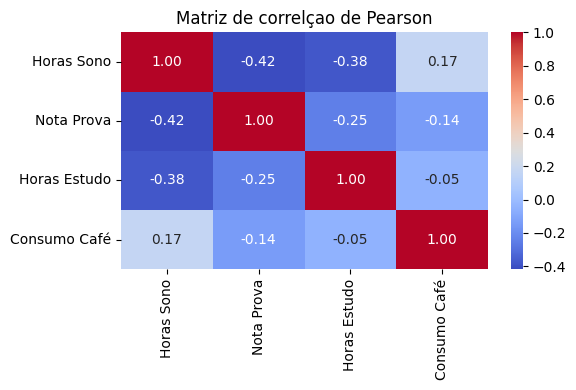

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#carregar o dataset externo

df = pd.read_csv('/content/drive/MyDrive/datasets/notas.csv')

#matriz de correlação de Pearson
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(method='pearson'), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Matriz de correlçao de Pearson')
plt.tight_layout()
plt.show()

**Calculando a Correlação Parcial em Python**

In [ ]:
!pip install pingouin
import pandas as pd
import pingouin as pg
from scipy.stats import pearsonr

#dados ficticios simulando correlacoes conhecidas
df =pd.DataFrame({
    'X':[1,20,35,40,50,60,35,10],
    'Y':[2,22,75,45,55,59,72,30],
    'Z':[8,16,25,35,41,54,63,10]
})

#correlacoes simples
r_xy, _ = pearsonr(df['X'],df['Y'])
r_xz, _ = pearsonr(df['X'],df['Z'])
r_yz, _ = pearsonr(df['Y'],df['Z'])

print(f'Correlacao X,Y:{r_xy:.2f}')
print(f'Correlacao X,Z:{r_xz:.2f}')
print(f'Correlacao Y,Z:{r_yz:.2f}')

#calculo da correlaçao parcial entre X e Y, controlando Z

resultado = pg.partial_corr(data=df, x='X', y='Y', covar='Z', method='pearson' )
print(resultado)



Correlacao X,Y:0.76
Correlacao X,Z:0.81
Correlacao Y,Z:0.76
         n         r           CI95     p_val
pearson  8  0.371227  [-0.53, 0.88]  0.412297


In [ ]:
import pandas as pd
import pingouin as pg
df = pd.read_csv('/content/drive/MyDrive/datasets/notas.csv')

resultado = pg.partial_corr(data=df, x='Nota Prova', y='Horas Estudo', covar=['Consumo Café', 'Horas Sono'], method='spearman')
print(resultado)

           n         r           CI95    p_val
spearman  20 -0.409964  [-0.74, 0.07]  0.09109


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/datasets/notas.csv')
list(df.columns)

['Horas Sono', 'Nota Prova', 'Horas Estudo', 'Consumo Café']

**Detecção univariada de outliers  pelo método IQR em Python**

In [ ]:
import numpy as np
import pandas as pd

#50 e um outlier
dados = pd.Series([7,8,9,10,11,12,13,50])

q1 = dados.quantile(0.25)
q3 = dados.quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = dados[(dados < limite_inferior) | (dados > limite_superior)]
print(outliers)


7    50
dtype: int64


**Gerando  boxplot para detecção de outliers em Python**

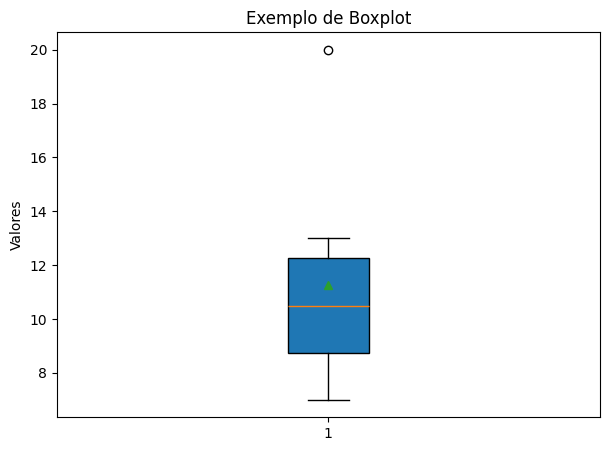

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dados = np.array([7,8,9,10,11,12,13,20]) #20 é o outlier

plt.figure(figsize=(7,5))
plt.boxplot(dados, vert=True, patch_artist = True, showmeans=True)
plt.ylabel('Valores')
plt.title('Exemplo de Boxplot')
plt.show()

**Detectando Outliers através do Z-score**

In [ ]:
import numpy as np
import pandas as pd

#20 e um possivel outlier

dados = np.array([7,8,9,10,11,12,13,20])
media = dados.mean()
desvio = dados.std()
zscore = (dados-media)/desvio
outliers = dados[np.abs(zscore)> 2]
print(outliers)

[20]


**Detectando outliers através da distancia de Mahalanobis**


In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

#dados de exemplo: idade e peso (ultima linha é um possivel outlier)
df = pd.DataFrame({
    'idade':[22,35,42,55,60,37,28,45,39,80],
    'peso':[65,80,77,90,85,78,68,82,75,100]

})

#calculo do centroide (media)
mu = df.mean().values

#matriz de covarianca
s = np.cov(df.values, rowvar=False, bias=True)
s_inv = np.linalg.inv(s)

#calculando Mahalanobis para cada ponto

df['mahalanobis'] = df.apply(lambda row: mahalanobis(row, mu, s_inv), axis=1)
print(df)

   idade  peso  mahalanobis
0     22    65     1.577164
1     35    80     1.918075
2     42    77     0.591169
3     55    90     1.474895
4     60    85     1.689559
5     37    78     0.878470
6     28    68     1.356386
7     45    82     0.547909
8     39    75     0.744839
9     80   100     2.233306


**calculando a inversa da Covariância em Python**

In [ ]:
import numpy as np
import pandas as pd
df = pd.DataFrame({'idade':[22,35,42,55], 'peso':[65,80,77,90]})
s = df.cov().values #matriz da covariancia
s_inv = np.linalg.inv(s) #inversa matriz

print(s)
print(s_inv)

[[189.66666667 134.        ]
 [134.         106.        ]]
[[ 0.04933292 -0.06236426]
 [-0.06236426  0.0882718 ]]


**Detectando outliers através do K-Means**

In [ ]:
import numpy as np

#dados de exemplo: 10 pontos 2D

x = np.random.rand(10,2)

#definindo número de clusters
k=2

#inicializaçãop aleatória dos centroides
indices = np.random.choice(len(x), k, replace=False)
centroids = x[indices]
for _ in range(4): #numero de iteracoes
  #atribuicao: encontra o centroide mais proximo
  labels = np.argmin(np.linalg.norm(x[:, np.newaxis] - centroids, axis = 2), axis=1)

  #atualizacao: recalcula a media de cada cluster
  for j in range(k):
    centroids[j] = x[labels==j].mean(axis=0)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# 10 pontos aleatórios
x = np.random.rand(10,2)

# transforma em DataFrame
df = pd.DataFrame(x, columns=['x1', 'x2'])

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(df)

df['cluster'] = kmeans.labels_

df['distancia'] = np.linalg.norm(
    df[['x1', 'x2']].values -
    kmeans.cluster_centers_[kmeans.labels_],
    axis=1
)

print(df)

         x1        x2  cluster  distancia
0  0.862447  0.155235        1   0.475575
1  0.924379  0.684241        0   0.261278
2  0.178871  0.498325        1   0.293154
3  0.524049  0.871849        0   0.198636
4  0.562162  0.574183        1   0.203036
5  0.975649  0.878690        0   0.256088
6  0.596775  0.525194        1   0.187813
7  0.088054  0.143896        1   0.448721
8  0.444911  0.511553        1   0.110667
9  0.461231  0.959887        0   0.282878


**Tratando Outliers**

**WINSORIZAÇÃO EM PYTHON**

In [ ]:
import numpy as np
from scipy.stats.mstats import winsorize

#produção diaria de leite (em litros) por vaca
leite = np.array([10,13,15,16,18,20,21,22,24,25])

#aplica winsorização de 10% em cada extremidade
leite_win = winsorize(leite, limits = [0.1, 0.1])

print("Original", leite)
print('Winsorizado:', leite_win)


Original [10 13 15 16 18 20 21 22 24 25]
Winsorizado: [13 13 15 16 18 20 21 22 24 24]


**Imputação de Outliers**

In [ ]:
import numpy as np

consumo = np.array([8,10,11,3,14,15,16,18,19,60,])

#calcule a mediana ignorando o outlier
mediana = np.median(consumo[consumo<50]) #supondo que 50 seja o outlier

#importa o outlier com a mediana
consumo_imp = np.where(consumo >50, mediana, consumo)

print(consumo_imp)

[ 8. 10. 11.  3. 14. 15. 16. 18. 19. 14.]


**Exercicios propostos** **Exercício 1** — Análise de Outliers

(a) Para cada variável numérica (bilheteria_milhoes, nota_rottentomatoes e oscars), identifique os outliers. Em seguida, determine qual método de detecção de outliers (boxplot, z-score ou IQR) é o mais adequado para cada variável e justifique sua escolha.

**Analisando a variavel bilheteria_milhoes**

1.8277655749581025
Dado a assimetria de 1.83, indicando cauda longa à direita
(assimetria positiva), decidi utilizar o método do IQR, já que o z-score
se sai melhor com variáveis cuja distribuição é mais simétrica.
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
os Outliers identificados  através do IQR foram: 
----------------------------------------------------------------------------------------------------
                                  filme  bilheteria_milhoes
12     Star Wars: O Despertar da Forca              2071.3
21   Homem-Aranha: Sem Volta Para Casa              1921.8
25                             Titanic              2264.7
109                             Avatar              2923.7
110          Avatar: O Caminho da Agua              2320.2
119               Vingadores: Ultimato              2799.4
120        Vingado

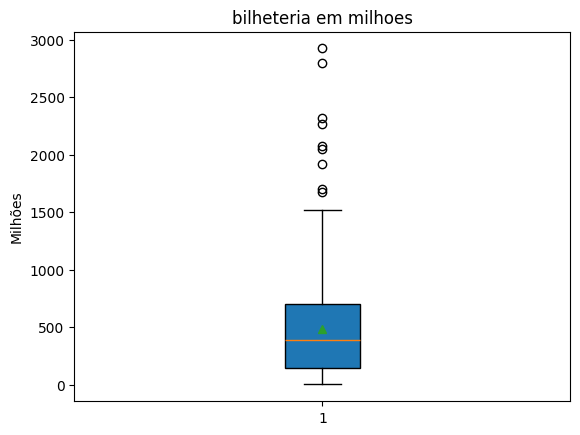

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('/content/drive/MyDrive/datasets/filmes.csv')

df.columns.tolist()  #lembrete das colunas
bilheteria = (df['bilheteria_milhoes'])
nota = (df['nota_rottentomatoes'])
oscars =(df['oscars'])

#descobrindo a assimetria ou simetria da bilheteria
assimetria = skew(bilheteria)
print(assimetria)
print(f"""Dado a assimetria de {assimetria:.2f}, indicando cauda longa à direita
(assimetria positiva), decidi utilizar o método do IQR, já que o z-score
se sai melhor com variáveis cuja distribuição é mais simétrica.""")


print('-'*100)
print('-'*100)

#calclulando o iqr e filtrando
q1_bilheteria = np.percentile(bilheteria, 25)
q3_bilheteria = np.percentile(bilheteria, 75)
iqr_bilheteria = q3_bilheteria - q1_bilheteria

limite_superior = q3_bilheteria + 1.5 * iqr_bilheteria
df_outliers_bilheteria = df[df['bilheteria_milhoes'] > limite_superior][['filme', 'bilheteria_milhoes']]
print(f'os Outliers identificados  através do IQR foram: \n{'-'*100}\n {df_outliers_bilheteria}')


#plotando o boxplot
plt.boxplot(bilheteria, vert=True, patch_artist=True,showmeans=True)
plt.ylabel('Milhões')
plt.title('bilheteria em milhoes')
plt.show()




**analisando a variavel nota_rottentomatoes**

-1.3713984331017712
----------------------------------------------------------------------------------------------------
Dado a assimetria de -1.37, indicando cauda longa à esquerda
(assimetria negativa), decidi utilizar o método do IQR, já que o z-score
se sai melhor com variáveis cuja distribuição é mais simétrica.
os Outliers identificados  através do IQR foram: 
----------------------------------------------------------------------------------------------------
                                        filme  nota_rottentomatoes
255  Transformers: A Vinganca dos Derrotados                   19
257          Transformers: A Era da Extincao                   18
270                  Cinquenta Tons de Cinza                   25
273                        Esquadrao Suicida                   26
279                                  Morbius                   15
284                      Quarteto Fantastico                    9
293                           A Mumia (2017)                   15
2

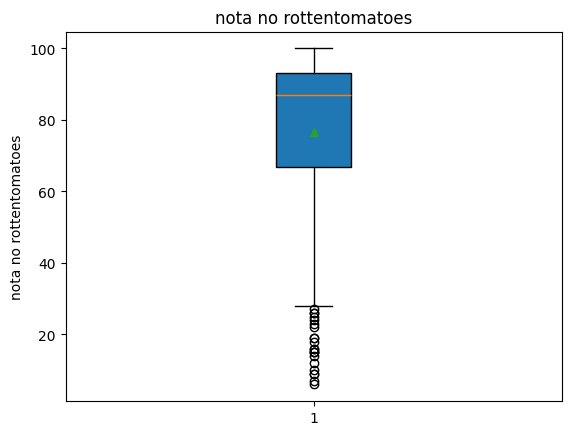

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew


df = pd.read_csv('/content/drive/MyDrive/datasets/filmes.csv')
df.columns.tolist()  #lembrete das colunas
nota = (df['nota_rottentomatoes'])


#descobrindo a assimetria ou simetria de nota_rottentomatoes
assimetria = skew(nota)
print(assimetria)

print("-"*100)
print(f"""Dado a assimetria de {assimetria:.2f}, indicando cauda longa à esquerda
(assimetria negativa), decidi utilizar o método do IQR, já que o z-score
se sai melhor com variáveis cuja distribuição é mais simétrica.""")

print('='*100)
print('='*100)


#calclulando o iqr e filtrando
q1_nota = np.percentile(nota, 25)
q3_nota = np.percentile(nota, 75)
iqr_nota = q3_nota - q1_nota
limite_inferior = q1_nota - 1.5 * iqr_nota

df_outliers_nota = df[df['nota_rottentomatoes'] < limite_inferior][['filme', 'nota_rottentomatoes']]
print(f'os Outliers identificados  através do IQR foram: \n{'-'*100}\n {df_outliers_nota}')


plt.boxplot(nota, vert=True, patch_artist=True,showmeans=True)
plt.ylabel('nota no rottentomatoes')
plt.title('nota no rottentomatoes')
plt.show()

**analisando a variavel oscars**



2.022942761903809
----------------------------------------------------------------------------------------------------
Dado a assimetria de 2.02, indicando cauda longa à direita
(assimetria positiva), decidi utilizar o método do IQR, já que o z-score
se sai melhor com variáveis cuja distribuição é mais simétrica.
os Outliers identificados  através do IQR foram: 
----------------------------------------------------------------------------------------------------
                                     filme  oscars
2    O Senhor dos Aneis: O Retorno do Rei      11
6           Star Wars: Uma Nova Esperanca       7
25                                Titanic      11
26                                Ben-Hur      11
28                   O Poderoso Chefao II       6
32                           Forrest Gump       6
35                            Oppenheimer       7
36      Tudo em Todo Lugar ao Mesmo Tempo       7
39                             La La Land       6
46                       Guerra a

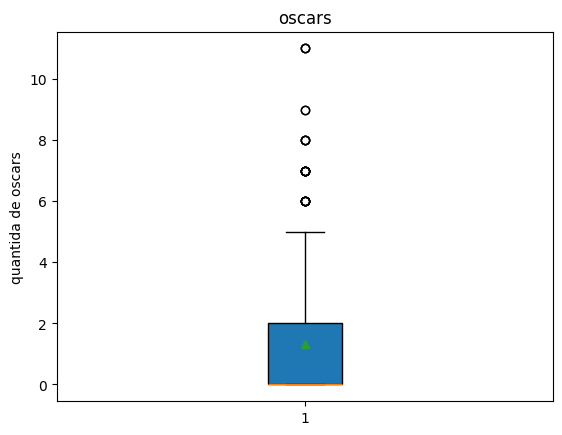

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
df = pd.read_csv('/content/drive/MyDrive/datasets/filmes.csv')

df.columns.tolist()  #lembrete das colunas
oscars = (df['oscars'])

#descobrindo a assimetria ou simetria de nota_rottentomatoes
assimetria = skew(oscars)
print(assimetria)
print("-"*100)

print(f"""Dado a assimetria de {assimetria:.2f}, indicando cauda longa à direita
(assimetria positiva), decidi utilizar o método do IQR, já que o z-score
se sai melhor com variáveis cuja distribuição é mais simétrica.""")
print('='*100)
print('='*100)

#calclulando o iqr e filtrando
q1_oscars = np.percentile(oscars, 25)
q3_oscars = np.percentile(oscars, 75)
iqr_oscars = q3_oscars - q1_oscars

limite_superior = q3_oscars + 1.5 * iqr_oscars
df_outliers_oscars = df[df['oscars'] > limite_superior][['filme', 'oscars']]
print(f'os Outliers identificados  através do IQR foram: \n{'-'*100}\n {df_outliers_oscars}')

plt.boxplot(oscars, vert=True, patch_artist=True,showmeans=True)
plt.ylabel('quantida de oscars')
plt.title('oscars')
plt.show()

**Exercicio 1 -(b)** Considerando agora as variáveis de forma multivariada, utilize K-Means e a distância de Mahalanobis para identificar possíveis outliers conjuntos. Quais filmes aparecem como casos extremos nessas análises?

**Detectando outliers do dataset filmes.csv atráves do metódo KMEANS**

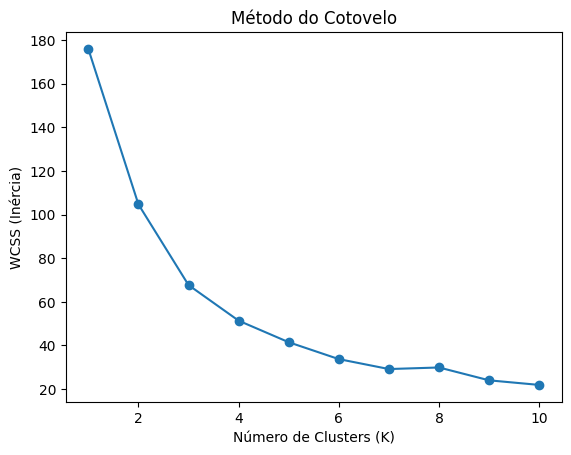

Dado a ánalise do  gráfico do métododo do cotovelo decidi escolher o valor de K como 5, 
pois a partir desse ponto a queda da inercia passa a ser menos significativa.
Valor da assimetria: 2.25
----------------------------------------------------------------------------------------------------
Dado a assimetria de 2.25, indicando cauda longa à direita
(assimetria positiva), decidi utilizar o método do IQR, já que o z-score
se sai melhor com variáveis cuja distribuição é mais simétrica.
No total foram 8 Outliers detectados e os Outliers multivariados identificados  através do Kmeans foram: 
----------------------------------------------------------------------------------------------------
                                     filme  oscars  bilheteria_milhoes  \
2    O Senhor dos Aneis: O Retorno do Rei      11              1156.2   
25                                Titanic      11              2264.7   
26                                Ben-Hur      11               146.9   
38        

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/drive/MyDrive/datasets/filmes.csv')

df.columns.tolist()  #lembrete das colunas
bilheteria = (df['bilheteria_milhoes'])
nota = (df['nota_rottentomatoes'])
oscars =(df['oscars'])

#Normalizando a escala dos dados para aplicar o Kmeans e descobrindo o valor de "k" mais adequado para o nosso dataset

colunas = ['bilheteria_milhoes',
           'nota_rottentomatoes',
           'oscars']

scaler = MinMaxScaler(feature_range=(-1,1))

df_normalizado = pd.DataFrame(
    scaler.fit_transform(df[colunas]),
    columns=colunas
)

#aplicando o metódo do joelho para descobrir o melhor valor para k
wcss = []
# Testando valores de K de 1 a 10
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
  kmeans.fit(df_normalizado)
  # Armazena o valor do WCSS (inércia)
  wcss.append(kmeans.inertia_)

# Plotando o gráfico do Método do Cotovelo
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Inércia)')
plt.show()

print("""Dado a ánalise do  gráfico do métododo do cotovelo decidi escolher o valor de K como 5,
pois a partir desse ponto a queda da inercia passa a ser menos significativa.""")

print('='*100)
print('='*100)

#Aplicando o Kmeans
kmeans = KMeans(n_clusters =5)
kmeans.fit(df_normalizado)

df['cluster'] = kmeans.labels_

df_distancia = df['distancia'] = np.linalg.norm(
    df_normalizado.values - kmeans.cluster_centers_[kmeans.labels_], axis=1
)


#aplicando o metódo univariado

assimetria = skew(df_distancia)
print(f'Valor da assimetria: {assimetria:.2f}')
print("-"*100)

print(f"""Dado a assimetria de {assimetria:.2f}, indicando cauda longa à direita
(assimetria positiva), decidi utilizar o método do IQR, já que o z-score
se sai melhor com variáveis cuja distribuição é mais simétrica.""")
print('='*100)
print('='*100)

#calclulando o iqr e filtrando
q1_distancia = np.percentile(df_distancia, 25)
q3_distancia = np.percentile(df_distancia, 75)
iqr_distancia = q3_distancia - q1_distancia

limite_superior = q3_distancia + 1.5 * iqr_distancia
df_outliers_kmeans = df[df['distancia'] > limite_superior][['filme', 'oscars', 'bilheteria_milhoes', 'nota_rottentomatoes']]
print(f'No total foram {len(df_outliers_kmeans)} Outliers detectados e os Outliers multivariados identificados  através do Kmeans foram: \n{'-'*100}\n {df_outliers_kmeans}')


#Cara, eu achando que tava indo rapido no livro, pensei errado. quanto mais vou evoluindo, mais dificil e trabalhoso os exercicios ficam.



**Detectando outliers através da distancia de Mahalanobis.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import mahalanobis
from scipy.stats import skew


df = pd.read_csv('/content/drive/MyDrive/datasets/filmes.csv')

df.columns.tolist()  #lembrete das colunas
bilheteria = (df['bilheteria_milhoes'])
nota = (df['nota_rottentomatoes'])
oscar =(df['oscars'])

#separando os valores que utlizaremos

df_valores = df[['bilheteria_milhoes','nota_rottentomatoes','oscars']]

#calculo do centroide

mu = df_valores.mean().values

#matriz da covariancia

s = np.cov(df_valores.values, rowvar = False)
s_inv =np.linalg.inv(s)

#calculando Mahlanobis para cada ponto

df_mahalanobis = df['Mahalanobis'] = df_valores.apply(lambda row: mahalanobis(row.values, mu, s_inv), axis = 1)

#aplicando o metódo univariado

assimetria = skew(df['Mahalanobis'])
print(f'Valor da assimetria: {assimetria:.2f}')
print("-"*100)

print(f"""Dado a assimetria de {assimetria:.2f}, indicando cauda longa à direita
(assimetria positiva), decidi utilizar o método do IQR, já que o z-score
se sai melhor com variáveis cuja distribuição é mais simétrica.""")
print('='*100)
print('='*100)

#calclulando o iqr e filtrando
q1_mahalanobis = np.percentile(df['Mahalanobis'], 25)
q3_mahalanobis = np.percentile(df['Mahalanobis'], 75)
iqr_mahalanobis = q3_mahalanobis - q1_mahalanobis

limite_superior = q3_mahalanobis + 1.5 * iqr_mahalanobis

#filtrando os outliers
df_outliers_mahalanobis = df[df['Mahalanobis'] > limite_superior][['filme', 'oscars', 'bilheteria_milhoes', 'nota_rottentomatoes']]
print(f'No total foram {len(df_outliers_mahalanobis)} Outliers detectados e os Outliers multivariados identificados  através do Mahalanobis foram: \n{'-'*100}\n {df_outliers_mahalonobis}')
print("-"*100)




Valor da assimetria: 2.01
----------------------------------------------------------------------------------------------------
Dado a assimetria de 2.01, indicando cauda longa à direita
(assimetria positiva), decidi utilizar o método do IQR, já que o z-score
se sai melhor com variáveis cuja distribuição é mais simétrica.
No total foram 26 Outliers detectados e os Outliers multivariados identificados  através do Mahalanobis foram: 
----------------------------------------------------------------------------------------------------
                                     filme  oscars  bilheteria_milhoes  \
2    O Senhor dos Aneis: O Retorno do Rei      11              1156.2   
12        Star Wars: O Despertar da Forca       0              2071.3   
21      Homem-Aranha: Sem Volta Para Casa       0              1921.8   
25                                Titanic      11              2264.7   
26                                Ben-Hur      11               146.9   
35                       

**Conclusões:** Detecção de outliers do dataset filmes.csv  utilizando os métodos **Mahalanobis** e **K-Means**  

In [ ]:
# Comparação entre os dois métodos multivariados
outliers_kmeans = df_outliers_kmeans['filme']
outliers_mahalanobis = df_outliers_mahalanobis['filme']

# Filmes que aparecem nos DOIS métodos (interseção)
intersecao = df_outliers_kmeans[df_outliers_kmeans['filme'].isin(outliers_mahalanobis)]

# Filmes que só o Mahalanobis detectou
so_mahalanobis = df_outliers_mahalanobis[~df_outliers_mahalanobis['filme'].isin(outliers_kmeans)]

print(f'K-Means detectou {len(outliers_kmeans)} outliers')
print(f'Mahalanobis detectou {len(outliers_mahalanobis)} outliers')
print(f'Aparecem nos dois métodos: {len(intersecao)}')
print('='*100)

print(f'Outliers detectados pelos DOIS métodos:\n{"-"*100}\n{intersecao}')
print('='*100)

print(f'Outliers detectados APENAS pelo Mahalanobis:\n{"-"*100}\n{so_mahalanobis}')
print('='*100)

print("""CONCLUSÃO

Os dois métodos discordaram bastante: o K-Means detectou 9 outliers e o
Mahalanobis 26. A diferença tem uma explicação clara.

O K-Means mede a distância de cada filme até o centro do seu próprio cluster,
enquanto o Mahalanobis mede a distância até um único centro (a média geral do
dataset). Por isso, filmes de nota muito baixa (Emoji: O Filme, As Branquelas,
Norbit) foram marcados como outliers pelo Mahalanobis, mas não pelo K-Means:
eles formam um grupo próprio, então ficam perto do centro do cluster deles.

Isso é exatamente o que o livro alerta: quando os dados apresentam clusters,
o Mahalanobis pode tratar um cluster inteiro como conjunto de outliers.

Como o método do cotovelo indicou K=5, o dataset de fato apresenta estrutura
de clusters. Por isso, numa situação real eu adotaria o K-Means como método
principal para esse conjunto de dados.

Os filmes da interseção são os candidatos mais robustos a outlier, já que
foram detectados independente do método usado.""")

K-Means detectou 8 outliers
Mahalanobis detectou 26 outliers
Aparecem nos dois métodos: 7
Outliers detectados pelos DOIS métodos:
----------------------------------------------------------------------------------------------------
                                    filme  oscars  bilheteria_milhoes  \
2    O Senhor dos Aneis: O Retorno do Rei      11              1156.2   
25                                Titanic      11              2264.7   
26                                Ben-Hur      11               146.9   
109                                Avatar       3              2923.7   
110             Avatar: O Caminho da Agua       1              2320.2   
119                  Vingadores: Ultimato       0              2799.4   
319                        Emoji: O Filme       0               217.8   

     nota_rottentomatoes  
2                     93  
25                    88  
26                    85  
109                   81  
110                   76  
119                   

**Exercicio 1 -(c)** Na sua opinião, os outliers encontrados devem ser removidos, corrigidos ou mantidos? Justifique sua decisão com base no contexto dos dados.

In [ ]:
print("""(c) Os outliers devem ser removidos, corrigidos ou mantidos?

RESPOSTA: Mantidos.

Dado o contexto dos dados e os dois métodos de detecção multivariada que usei
(K-Means e Mahalanobis), não vejo motivo pra tratar esses outliers.

Os valores que apareceram são todos reais. Avatar arrecadou 2.9 bilhões mesmo,
Titanic ganhou 11 Oscars mesmo, e Emoji: O Filme tem nota 6 mesmo. Não são erro
de digitação nem de medição, então não tem o que corrigir.

E remover seria jogar fora dado verdadeiro. O mercado de cinema tem blockbuster
gigante e fracasso de crítica, isso faz parte do que o dataset representa. Tirar
esses casos ia distorcer a realidade em vez de melhorar a análise.""")

(c) Os outliers devem ser removidos, corrigidos ou mantidos?

RESPOSTA: Mantidos.

Dado o contexto dos dados e os dois métodos de detecção multivariada que usei
(K-Means e Mahalanobis), não vejo motivo pra tratar esses outliers.

Os valores que apareceram são todos reais. Avatar arrecadou 2.9 bilhões mesmo,
Titanic ganhou 11 Oscars mesmo, e Emoji: O Filme tem nota 6 mesmo. Não são erro
de digitação nem de medição, então não tem o que corrigir.

E remover seria jogar fora dado verdadeiro. O mercado de cinema tem blockbuster
gigante e fracasso de crítica, isso faz parte do que o dataset representa. Tirar
esses casos ia distorcer a realidade em vez de melhorar a análise.



**Exercicio 2- Correlação e Associação:(a)**  Calcule o coeficiente de correlação de Pearson entre bilheteria_milhoes e nota_rottentomatoes. O resultado indica associação forte, moderada ou fraca?

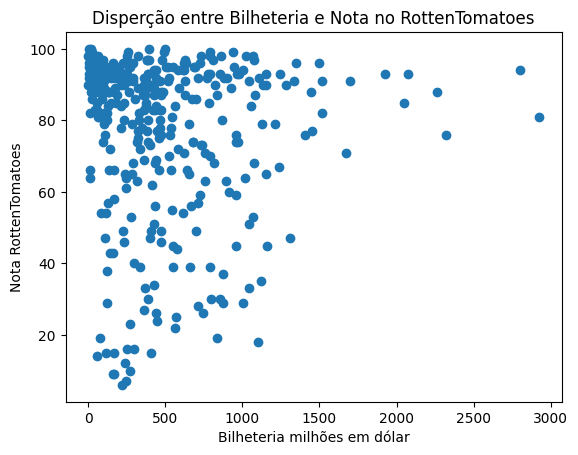

O coeficiente de Correlção de Pearson é de -0.04, indicando ausência de uma correlação.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('/content/drive/MyDrive/datasets/filmes.csv')

#definindo as colunas que trabalharemos
df_bilheteria_notas = df[['bilheteria_milhoes', 'nota_rottentomatoes']]

#afim de seguir o modo didático do livro irei plotar um gráfico de dispersão para termos uma noção de como os dados esntão distribuidos entre as duas variavies

plt.scatter(df['bilheteria_milhoes'], df['nota_rottentomatoes'])
plt.title('Disperção entre Bilheteria e Nota no RottenTomatoes')
plt.xlabel('Bilheteria milhões em dólar')
plt.ylabel('Nota RottenTomatoes')
plt.show()

print("="*100)
print("="*100)

#calculando o coeficiente de correlação de Pearson entre bilheteria_milhoes e nota_rottentomatoes. (utilizarei tanto o numpy quanto o panda para fins didáticos.)

x = df_bilheteria_notas['bilheteria_milhoes']
y = df_bilheteria_notas['nota_rottentomatoes']

#utilizando o Numpy
pearson_np =np.corrcoef(x,y)[0,1]

#utilizando pandas
pearson_pd = x.corr(y, method='pearson')

#conclusão
print(f'''O coeficiente de Correlção de Pearson é de {pearson_pd:.2f}, indicando ausência de uma correlação.''')










**Exercicio 2- Correlação e Associação:(b)** Faça uma análise de correlação parcial, controlando para o número de Oscars. O que muda em relação à correlação simples?

In [ ]:

import pandas as pd
import pingouin as pg
import numpy as np
from scipy.stats import pearsonr



df = pd.read_csv('/content/drive/MyDrive/datasets/filmes.csv')

#definindo as colunas que trabalharemos
df_bilheteria_notas_oscar = df[['bilheteria_milhoes', 'nota_rottentomatoes', 'oscars']]

#calculando o coeficiente de correlação de Pearson entre bilheteria_milhoes e nota_rottentomatoes controlados pelo núemor de Oscars

x = df_bilheteria_notas_oscar['bilheteria_milhoes']
y = df_bilheteria_notas_oscar['nota_rottentomatoes']
z = df_bilheteria_notas_oscar['oscars']

#correlaçoes simples
r_xy = np.corrcoef(x,y)[0,1]
r_xz = np.corrcoef(x,z)[0,1]
r_yz = np.corrcoef(y,z)[0,1]

#calculo de correlação parcial entre x e y, controlando z

resultado = pg.partial_corr(data=df_bilheteria_notas_oscar, x='bilheteria_milhoes', y='nota_rottentomatoes', covar='oscars', method='pearson')
resultado = resultado.loc['pearson','r' ]

print(f'''A correlação parcial de bilheteria_milhoes e nota_rottentomatoes ({r_xy:.2f}) controlada pela varial oscars é de:{resultado:.2f}.
 Houve uma aproximação de 0 no Coeficiente, indicando um efeito da variavel oscars na correlação entre bilheteria_milhoes
 e nota_rottentomatoes, mas ainda assim sem associação de correlação.  ''')






A correlação parcial de bilheteria_milhoes e nota_rottentomatoes (-0.04) controlada pela varial oscars é de:-0.02.
 Houve uma aproximação de 0 no Coeficiente, indicando um efeito da variavel oscars na correlação entre bilheteria_milhoes 
 e nota_rottentomatoes, mas ainda assim sem associação de correlação.  



**Exercicio 2- Correlação e Associação:(c)** Plote a matriz de correlação entre as três variáveis numéricas do dataset. Comente os principais achados observados.

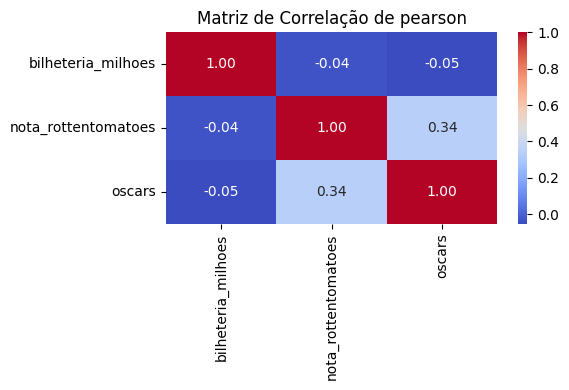

Análisando a matriz de correlação, é possivel identificar que há uma correlação positiva moderada entre nota_rottentomatoes e oscars.
nos resultados restante não apresentam uma associação de correlação.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/datasets/filmes.csv')

#definindo as colunas que trabalharemos
df_bilheteria_notas_oscar = df[['bilheteria_milhoes', 'nota_rottentomatoes', 'oscars']]

#matriz de correlação de pearson
plt.figure(figsize=(6,4))
sns.heatmap(df_bilheteria_notas_oscar.corr(method='pearson'), annot =True, cmap ='coolwarm', fmt ='.2f')
plt.title('Matriz de Correlação de pearson')
plt.tight_layout()
plt.show()

print('='*100)
print('='*100)

print(f'''Análisando a matriz de correlação, é possivel identificar que há uma correlação positiva moderada entre nota_rottentomatoes e oscars.
nos resultados restante não apresentam uma associação de correlação.''')

